# Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [4]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

# Dataset Preparation

The data are read from all samples in the given folder (desktop applications). From the source JSON we extract only the following (numerical) features:

* Flow Data: A subset of columns that contain numerical flow metrics ('BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration') is extracted from the DataFrame. These values are converted to a NumPy array of type float32.
* TLS Records size sequence: The 'RecordSequence' column, which holds sequences (arrays) of integers is taken and the array is padded or truncated so that its length is exactly RECORD_SEQUENCE_SIZE (20). These values are converted to a NumPy array of type float32.

The processed numerical flow data and the padded record sequences are concatenated horizontally (column-wise) such that each row has exactly 25 columns. Any NaN values in the concatenated dataset are replaced with 0.

For each column in the dataset, the minimum and maximum values are computed. A min-max normalization is then applied column-wise. This rescales every value so that each feature (column) lies in the range [0,1].

`normal_df` is prepared and can be used for the autoencoder training.

In [6]:
import json
import glob
import pandas as pd
import numpy as np
from array import array
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

RECORD_SEQUENCE_SIZE=20
tls_columns_names = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Resize row in the array
def resize_row(row, maxlen, pad_value=0):
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end (you can also pad at the beginning or both sides)
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row
# Resize the matrix by padding or removing columns
def pad_sequences(rows, maxlen, pad_value=0):
    resized_rows = [resize_row(row, maxlen) for row in rows]
    return resized_rows

# Loads data from the specified collection of json files. It provides raw data.
def load_json_files(json_files):
    all_data = []
    # Open the file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Use a list comprehension to load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            for item in data: all_data.append(item)
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

# Extracts features from raw dataset. This will provide suitable output to the preprocessing pipeline.
# Flow related columns: 'BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration'
# TLS handshake columns: 'TlsClientVersion','TlsServerVersion','TlsServerCipherSuite'
# TLS record sizes: 'RecordSequence' mapped as 'TlsRecord_X'
#
# The output is a DataFrame with the above specified columns. This dataframe can beused as the input to next
# processing block (preprocessor).
#
def extract_features(df):
    # Flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    # TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    # TLS records 
    records_data = pd.DataFrame( pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), columns=tls_columns_names)
    dataset = pd.concat([flow_data, tls_data, records_data], axis=1).fillna(0)
    return dataset
#
# Fits the preprocessor that contains scalers for numerical features and OneHotEncoder for categorical data.
# The result is the Pipeline that can be used for further data processing before they are fed in the Autoencoder.
# 
def fit_preprocessor(df):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
            ('num_tls', MinMaxScaler(), tls_columns_names),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
        ])
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    pipeline.fit(df)
    return pipeline


# -------------------------------------------------
# Load normal data and prepare them for Autoencoder
# Normal data are for now represented as the desktop application communication.
#
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'dataset shape={raw_df.shape}')
input_df = extract_features(raw_df)

pipeline = fit_preprocessor(input_df)
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])

print(f'dataset shape={normal_df.shape}')

dataset shape=(3304, 28)
Normalized row of data:
[0.08647509 0.11764706 0.00538477 0.0273224  0.00150611 0.71300448
 0.02653095 0.01972047 0.06239804 0.3551694  0.76715686 0.09642262
 0.16600588 0.40854912 0.00993807 0.93248369 0.09416709 0.08356497
 0.04919743 0.04921739 0.07309908 0.27012594 0.073128   0.03078832
 0.06424374 0.         1.         0.         1.         0.
 1.         0.         0.         0.         0.        ]
dataset shape=(3304, 35)


# Autoencoder Training

The autoencoder is trained on `normal_df`. The data are split into training (80%) and testing (20%) parts. The size of laten space is set to `LATENT_SPACE_SIZE`.

The results are visualzied for the 10 selected sample. 

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

train shape=(2643, 35)
test shape=(661, 35)
Epoch 1/50


166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6563 - val_loss: 0.4459
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4012 - val_loss: 0.3468
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3425 - val_loss: 0.3282
Epoch 4/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3236 - val_loss: 0.3105
Epoch 5/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3065 - val_loss: 0.2957
Epoch 6/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2919 - val_loss: 0.2844
Epoch 7/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2791 - val_loss: 0.2757
Epoch 8/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2714 - val_loss: 0.2690
Epoch 9/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2665 - val_loss: 0.2638
Epoch 10/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2604 - val_loss: 0.2596
Epoch 11/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2571 - val_loss: 0.2562
Epoch 12/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

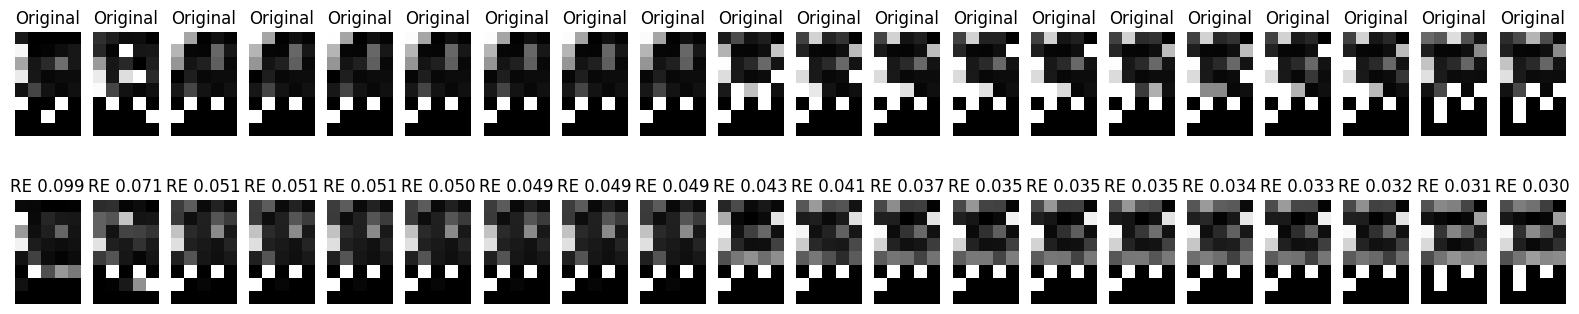

In [9]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
LATENT_SPACE_SIZE=6

# 1. Split data to traingin and testing
x_train, x_test = train_test_split(normal_df, test_size=0.2)
print(f'train shape={x_train.shape}')
print(f'test shape={x_test.shape}')

# 2. Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Input placeholder
input_img = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model for later use
encoder = Model(input_img, encoded)

# Decoder model setup
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# 3. Compile and train the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=50,                      # use some more reasonable number here (>50)
                batch_size=16,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Visualize the reconstructed images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Assuming x_test contains the original test data
# and decoded_imgs are the autoencoder's reconstructed outputs
reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

# Average reconstruction error across all samples
avg_error = np.mean(reconstruction_errors)
max_error = np.max(reconstruction_errors)
min_error = np.min(reconstruction_errors)
print(f"Reconstruction error for each sample {reconstruction_errors}")
print(f"Average={avg_error}, Max={max_error}, Min={min_error} reconstruction errors.")

# Get indices that would sort the array in ascending order
worst20 = np.argsort(reconstruction_errors)[-20:][::-1]

n = 20  # Number of digits to display
i = 0

print("Worst reconstructed:")
plt.figure(figsize=(20, 4))
for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = np.pad(original, pad_width=(0,5), mode='constant', constant_values=0).reshape(8, 5) 
    reconstructed = decoded_imgs[j]
    reconstructed = np.pad(reconstructed, pad_width=(0,5), mode='constant', constant_values=0).reshape(8, 5) 
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i+=1
plt.show()


# Test with unknown data

Next, we load ISCX data set and use previously trained Autoencoder. The reconstruction error shuld be significantly higher.

In [12]:
def test_dataset(json_files):
    raw_test_df = load_json_files(json_files)
    print(f'raw dataset shape={raw_test_df.shape}')
    input_test_df = extract_features(raw_test_df)
    test_df = pipeline.transform(input_test_df)

    print('Normalized row of data:')
    print(test_df[0])
    print(f'dataset shape={test_df.shape}')

    encoded_test = encoder.predict(test_df)
    decoded_test = decoder.predict(encoded_test)

    # Assuming x_test contains the original test data
    # and decoded_imgs are the autoencoder's reconstructed outputs
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)

    # Get indices that would sort the array in ascending order
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]

    # Average reconstruction error across all samples
    test_avg_error = np.mean(test_reconstruction_errors)
    print("Reconstruction error for each sample:", test_reconstruction_errors)
    print("Average reconstruction error:", test_avg_error)

    print("Worst reconstructed:")
    n = 10  # Number of digits to display
    i = 0
    plt.figure(figsize=(20, 4))
    for j in worst10:
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = np.pad(original, pad_width=(0,5), mode='constant', constant_values=0).reshape(8, 5) 
        reconstructed = decoded_test[j]
        reconstructed = np.pad(reconstructed, pad_width=(0,5), mode='constant', constant_values=0).reshape(8, 5) 
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
        i+=1
    plt.show()

raw dataset shape=(1670, 28)
Normalized row of data:
[4.62694437e-02 7.05882353e-01 0.00000000e+00 0.00000000e+00
 1.08441171e+01 1.00946687e+00 6.17386951e-03 1.95290063e-02
 5.81158238e-02 9.20115014e-02 6.49509804e-01 8.96268752e-02
 1.66133777e-01 4.30332922e-01 9.04508138e-02 9.21256259e-01
 8.99642188e-02 2.96291916e-02 4.91974271e-02 4.92173913e-02
 7.30990848e-02 2.70125940e-01 7.31280023e-02 3.07883229e-02
 6.42437382e-02 1.00000000e+00 0.00000000e+00 1.00000000e+00
 0.00000000e+00 1.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(1670, 35)
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Reconstruction error for each sample: [2.88619848 2.88618148 0.01343563 ... 0.10399127 0.24739615 0.21240073]
Average reconstruction error: 8.13888547897396
Worst reconstructed:


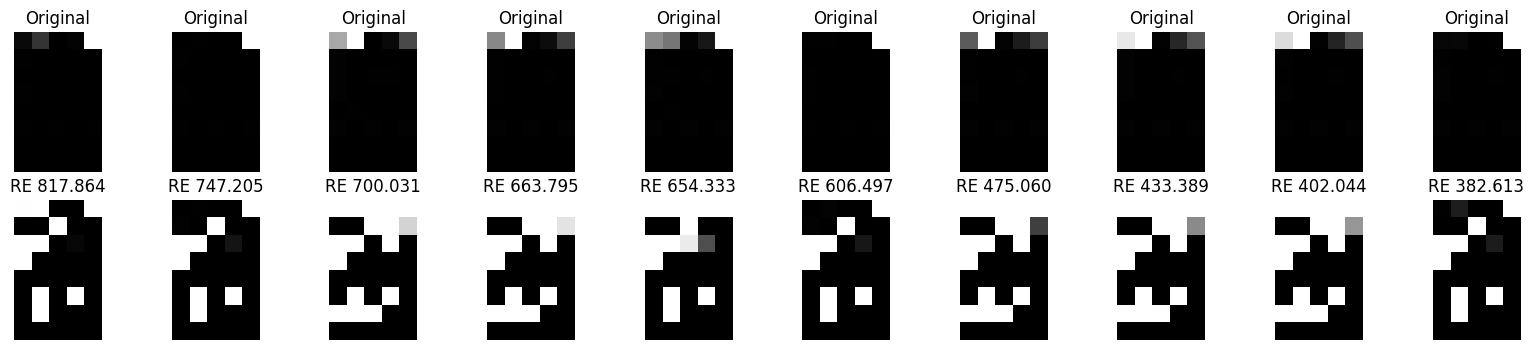

In [13]:
test_dataset(json_files=glob.glob("../datasets/iscx.tls/*.json"))

raw dataset shape=(7430, 28)
Normalized row of data:
[0.08311363 0.23529412 0.04713872 0.15846995 0.00253027 0.75435974
 0.02653095 0.01972047 0.28119902 0.09188649 0.58455882 0.0784716
 0.1277657  0.61323469 0.09866052 0.91731149 0.0914409  0.05417233
 0.05157327 0.12956522 0.15139532 0.33180544 0.15145521 0.11269354
 0.14332173 0.         1.         0.         1.         0.
 1.         0.         0.         0.         0.        ]
dataset shape=(7430, 35)
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction error for each sample: [0.00223905 0.00019073 0.03910992 ... 0.00140039 0.00577456 0.00280369]
Average reconstruction error: 0.24074451601072572
Worst reconstructed:


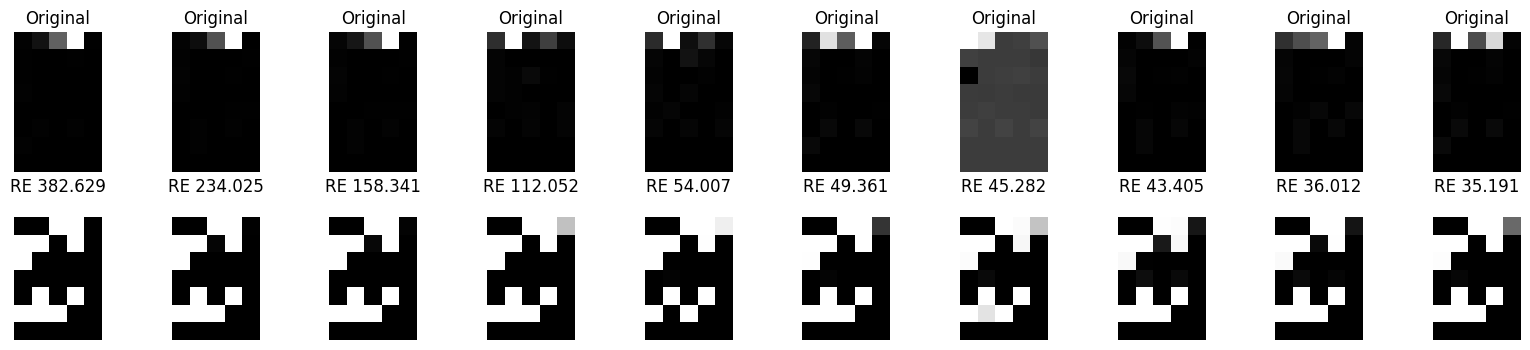

In [14]:
test_dataset(glob.glob("../datasets/mobile.tls/*.json"))